---
description: "Robust regression as an LO model: fitting a line by minimizing the sum of absolute errors, and the trick that makes absolute values linear."
thumbnail: null
---
# Lecture 10: Robust Regression

[![Open In Colab](images/colab-badge.svg)](https://colab.research.google.com/github/UvA-SSO/simopt-lecture-notes/blob/main/notebooks/lecture10_robust-regression.ipynb)

This notebook covers robust regression: fitting a line through data points such that
the sum of the absolute prediction errors is as small as possible, which makes the line
far less sensitive to outliers than ordinary least squares. The absolute value is not
linear, so the model needs a trick that splits each error into a positive and a
negative part; the same trick linearizes absolute values in other models. Like the
applications of [Lecture 9](lecture9_introduction.ipynb) and
[Multi-Period Inventory Planning](lecture10_multi-period.ipynb), the problem is
introduced in the same steps: a practical motivation, the generic model built up with
the [four modeling steps](lecture8_linear-optimization.ipynb#modeling-approach), the
model for a concrete example, its solution in pulp, and possible extensions.

**Learning outcomes**

On completion of this notebook, you will be able to:

- formulate a robust regression problem as an LO model;
- linearize absolute values in a model with the $e = e^+ - e^-$ split;
- adapt the model to quantile regression.

(robust-regression)=
## Robust Regression

### Practical Motivation

A factory wants to predict how long a production order will take from its size, to
promise delivery dates. It fits a line through the data of past orders. A few of those
orders took far longer than usual, for example because a machine broke down.
Ordinary least-squares (OLS) regression minimizes the sum of *squared* prediction
errors, so such outliers have a large influence and pull the line toward them, just as
a single extreme value pulls the mean. Minimizing the sum of *absolute* errors instead
gives a line that is far less sensitive to outliers, the line analogue of the median.
This is called **robust regression** (or least absolute deviation regression).

### Modeling

#### Problem Definition and Example

Given $n$ data points $(x_i, y_i)$, $i = 1, \dots, n$, find the line $a + bx$ that
minimizes the sum of the absolute prediction errors $|y_i - (a + b x_i)|$.

As an example, take the five data points

| $i$ | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|
| $x_i$ | 2 | 4 | 6 | 8 | 10 |
| $y_i$ | 5 | 4 | 9 | 3 | 7 |

which we store as numpy arrays and plot in [](#fig-regression-data).

In [ ]:
import numpy as np
import plotly.graph_objects as go
import pulp

xs = np.array([2, 4, 6, 8, 10])
ys = np.array([5, 4, 9, 3, 7])
points = range(len(xs))

In [ ]:
TEXT_COLOR = "#111827"
PLOT_LAYOUT = {
    "paper_bgcolor": "rgba(0,0,0,0)",
    "plot_bgcolor": "rgba(0,0,0,0)",
    "font": {"color": TEXT_COLOR, "size": 13},
    "margin": {"l": 50, "r": 20, "t": 20, "b": 50},
    "height": 380,
    "legend": {
        "bgcolor": "rgba(0,0,0,0)",
        "orientation": "h",
        "yanchor": "top",
        "y": -0.2,
    },
}
AXIS_STYLE = {
    "gridcolor": "rgba(128,128,128,0.25)",
    "zerolinecolor": "rgba(128,128,128,0.5)",
}
# static pictures: no hover, zoom or drag
PLOT_CONFIG = {"displayModeBar": False, "staticPlot": True}
X_RANGE = [-0.5, 11]
SUBSCRIPT = "₀₁₂₃₄₅₆₇₈₉"


def data_figure() -> go.Figure:
    """The example data points, with the axes used in every plot."""
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=xs,
            y=ys,
            mode="markers",
            marker={"size": 10, "color": "#1f77b4"},
            name="data points",
        )
    )
    fig.update_layout(**PLOT_LAYOUT)
    fig.update_xaxes(title="x", range=X_RANGE, dtick=2, **AXIS_STYLE)
    fig.update_yaxes(title="y", range=[0, 12], dtick=2, **AXIS_STYLE)
    return fig


def add_line(
    fig: go.Figure, a: float, b: float, name: str, color: str, dash: str
) -> None:
    """Add the line a + bx over the plotted x range."""
    line_x = np.array(X_RANGE)
    fig.add_trace(
        go.Scatter(
            x=line_x,
            y=a + b * line_x,
            mode="lines",
            line={"color": color, "dash": dash, "width": 2},
            name=name,
        )
    )

In [ ]:
data_figure().show(config=PLOT_CONFIG)

:::{figure} #regression-data
:label: fig-regression-data

The five data points of the example.
:::

#### Decision Variables

We choose the line, so its intercept $a$ and slope $b$ are decision variables. Both
may be negative, so unlike in most models so far they have no sign constraint. It
helps to also introduce the prediction error of each data point as a variable,

$$
e_i = y_i - (a + b x_i), \quad i = 1, \dots, n.
$$

#### Objective

We want to minimize $\sum_{i=1}^{n} |e_i|$. The absolute value is not linear, so this
is not yet an LO model. There is a standard trick to fix this. Write each error as the
difference of two non-negative variables,

$$
e_i = e_i^+ - e_i^-, \quad e_i^+, e_i^- \ge 0,
$$

and replace $|e_i|$ by $e_i^+ + e_i^-$ in the objective, which is linear:

$$
\min \sum_{i=1}^{n} (e_i^+ + e_i^-).
$$

Why is this allowed? The same $e_i$ can be written as $e_i^+ - e_i^-$ in many ways,
for example $2 = 2 - 0 = 5 - 3$. But if both $e_i^+$ and $e_i^-$ were positive, we
could lower both by the same amount: $e_i$ stays the same and the objective goes down.
So at the optimum, at least one of the two is 0, and then $e_i^+ + e_i^- = |e_i|$. If
$e_i^+ > 0$, the data point lies $e_i^+$ above the line; if $e_i^- > 0$, it lies
$e_i^-$ below the line.

[](#fig-error-split) shows this for the example and the line with $a = 3$ and
$b = 0.5$, which is not the optimal one. The line crosses the $y$-axis at height
$a = 3$ and rises $b = 0.5$ for every unit that $x$ increases. Data points 1 and 3
lie above the line, with $e_1^+ = 1$ and $e_3^+ = 3$; data points 2, 4 and 5 lie
below it, with $e_2^- = 1$, $e_4^- = 4$ and $e_5^- = 1$. All other $e_i^+$ and
$e_i^-$ are 0, and the objective value of this line is $1 + 1 + 3 + 4 + 1 = 10$.

In [ ]:
trial_a, trial_b = 3, 0.5
# label placement per data point (anchor, x shift, y shift), clear of the
# line and the slope step
LABEL_PLACE = {
    0: ("right", -6, 0),
    1: ("left", 6, 0),
    2: ("left", 6, 0),
    3: ("left", 6, 0),
    4: ("center", 0, 30),
}
split = data_figure()
add_line(split, trial_a, trial_b, "line a + bx", "#7f7f7f", "dash")
for sign, color in [("+", "#ff7f0e"), ("-", "#9467bd")]:
    seg_x: list[float | None] = []
    seg_y: list[float | None] = []
    for k in points:
        on_line = trial_a + trial_b * xs[k]
        error = ys[k] - on_line
        if (error > 0) != (sign == "+") or error == 0:
            continue
        seg_x += [xs[k], xs[k], None]
        seg_y += [on_line, ys[k], None]
        label = f"e{SUBSCRIPT[k + 1]}{'⁺' if sign == '+' else '⁻'}"
        anchor, x_shift, y_shift = LABEL_PLACE[k]
        split.add_annotation(
            x=xs[k],
            y=(on_line + ys[k]) / 2,
            text=f"{label} = {abs(error):g}",
            xanchor=anchor,
            xshift=x_shift,
            yshift=y_shift,
            showarrow=False,
        )
    split.add_trace(
        go.Scatter(
            x=seg_x,
            y=seg_y,
            mode="lines",
            line={"color": color, "width": 3},
            name="e⁺ (above the line)" if sign == "+" else "e⁻ (below)",
        )
    )
# the intercept a, and the slope b as a step of 2 in x
split.add_trace(
    go.Scatter(
        x=[0, 2, 2],
        y=[trial_a, trial_a, trial_a + 2 * trial_b],
        mode="lines+markers",
        marker={"size": [8, 0, 0], "color": "#17becf"},
        line={"color": "#17becf", "width": 2},
        name="slope: +2 in x gives +2b in y",
        showlegend=True,
    )
)
split.add_annotation(
    x=0,
    y=trial_a,
    text=f"a = {trial_a}",
    xanchor="left",
    xshift=4,
    yshift=-14,
    showarrow=False,
)
split.add_annotation(
    x=2,
    y=trial_a + trial_b,
    text=f"2b = {2 * trial_b:g}",
    xanchor="left",
    xshift=4,
    showarrow=False,
)
split.show(config=PLOT_CONFIG)

:::{figure} #error-split
:label: fig-error-split

The data points of the example and the line $3 + 0.5x$ (not optimal). A data point
above the line has a positive error $e_i^+$, a data point below it a positive
$e_i^-$. The line starts at height $a = 3$ on the $y$-axis and rises by $2b = 1$ when
$x$ increases by 2.
:::

#### Constraints

The only constraints connect the errors to the line:

$$
e_i^+ - e_i^- = y_i - (a + b x_i), \quad i = 1, \dots, n,
$$

together with $e_i^+, e_i^- \ge 0$. The variables $a$ and $b$ are free.

#### Complete LO Model

$$
\begin{aligned}
\min \quad & \sum_{i=1}^{n} (e_i^+ + e_i^-) \\
\text{s.t.} \quad & e_i^+ - e_i^- = y_i - (a + b x_i), \quad i = 1, \dots, n \\
& e_i^+, e_i^- \ge 0, \quad i = 1, \dots, n.
\end{aligned}
$$

### Modeling the Example

$$
\begin{aligned}
\min \quad & \sum_{i=1}^{5} (e_i^+ + e_i^-) \\
\text{s.t.} \quad & e_1^+ - e_1^- = 5 - (a + 2b) \\
& e_2^+ - e_2^- = 4 - (a + 4b) \\
& e_3^+ - e_3^- = 9 - (a + 6b) \\
& e_4^+ - e_4^- = 3 - (a + 8b) \\
& e_5^+ - e_5^- = 7 - (a + 10b) \\
& e_i^+, e_i^- \ge 0, \quad i = 1, \dots, 5.
\end{aligned}
$$

### Solving the Example in pulp

A variable without `lowBound` is free in pulp (its bounds default to $-\infty$ and
$\infty$), which is what we need for the intercept and the slope. The data points are
the numpy arrays `xs` and `ys` from above, which pulp's expressions accept like
ordinary numbers.

In [1]:
robust_regression = pulp.LpProblem(
    name="robust_regression", sense=pulp.LpMinimize
)
intercept = pulp.LpVariable(name="a")
slope = pulp.LpVariable(name="b")
e_pos = [pulp.LpVariable(name=f"ep_{k + 1}", lowBound=0) for k in points]
e_neg = [pulp.LpVariable(name=f"en_{k + 1}", lowBound=0) for k in points]

robust_regression += pulp.lpSum(e_pos[k] + e_neg[k] for k in points)
for k in points:
    prediction = intercept + slope * xs[k]
    robust_regression += ys[k] - prediction == e_pos[k] - e_neg[k]

robust_regression.solve(pulp.PULP_CBC_CMD(msg=False))
a_hat, b_hat = intercept.value(), slope.value()
print("status:", pulp.LpStatus[robust_regression.status])
print(f"line: y = {a_hat:.2f} + {b_hat:.2f} x")
print("sum of absolute errors:", robust_regression.objective.value())

status: Optimal
line: y = 4.50 + 0.25 x
sum of absolute errors: 8.0


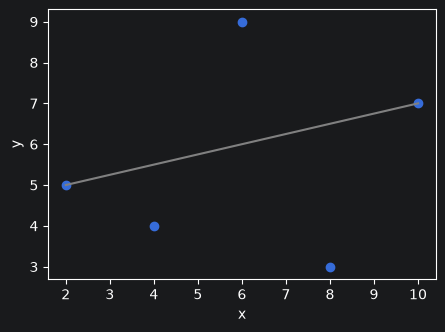

In [2]:
fit = data_figure()
add_line(fit, a_hat, b_hat, f"{a_hat:g} + {b_hat:g}x", "#7f7f7f", "solid")
fit.show(config=PLOT_CONFIG)

:::{figure} #robust-fit
:label: fig-robust-fit

The five data points of the example and the line $y = 4.5 + 0.25x$ that minimizes the
sum of absolute errors.
:::

The optimal line passes exactly through the first and the last data point. That is no
coincidence: as in every LO problem, there is an optimal solution in a corner point,
and for this model that means a line through (at least) two of the data points. Its
objective value is 8, lower than the 10 of the line in [](#fig-error-split).

### Extensions

#### Quantile Regression

Weighting the two parts of the error differently tilts the line toward the upper or
lower points. For a quantile level $0 < p < 1$, the model becomes

$$
\begin{aligned}
\min \quad & p \sum_{i=1}^{n} e_i^+ + (1 - p) \sum_{i=1}^{n} e_i^- \\
\text{s.t.} \quad & e_i^+ - e_i^- = y_i - (a + b x_i), \quad i = 1, \dots, n \\
& e_i^+, e_i^- \ge 0, \quad i = 1, \dots, n.
\end{aligned}
$$

This is **quantile regression**. With $p = 0.5$, both parts get the same weight, which
gives the same optimal lines as robust regression (the objective is just halved).
With $p = 0.9$, a point above the line costs 9 times as much as a point below it, so
the line moves up until about 90% of the data points lie below it. This is useful for
promising delivery times that are met in 90% of the cases. Only the objective changes
in the pulp model:

In [ ]:
quantile_line = {}
for p in [0.5, 0.9]:
    quantile_regression = pulp.LpProblem(
        name="quantile_regression", sense=pulp.LpMinimize
    )
    intercept = pulp.LpVariable(name="a")
    slope = pulp.LpVariable(name="b")
    e_pos = [pulp.LpVariable(name=f"ep_{k + 1}", lowBound=0) for k in points]
    e_neg = [pulp.LpVariable(name=f"en_{k + 1}", lowBound=0) for k in points]

    above = pulp.lpSum(e_pos)
    below = pulp.lpSum(e_neg)
    quantile_regression += p * above + (1 - p) * below
    for k in points:
        prediction = intercept + slope * xs[k]
        quantile_regression += ys[k] - prediction == e_pos[k] - e_neg[k]

    quantile_regression.solve(pulp.PULP_CBC_CMD(msg=False))
    quantile_line[p] = (intercept.value(), slope.value())
    print(f"p = {p}: y = {intercept.value():.2f} + {slope.value():.2f} x")

In [ ]:
quantile_fig = data_figure()
styles = {0.5: ("#7f7f7f", "solid"), 0.9: ("#d62728", "dash")}
for p, (a_p, b_p) in quantile_line.items():
    color, dash = styles[p]
    add_line(
        quantile_fig, a_p, b_p, f"p = {p}: {a_p:g} + {b_p:g}x", color, dash
    )
quantile_fig.show(config=PLOT_CONFIG)

:::{figure} #quantile-fit
:label: fig-quantile-fit

Quantile regression on the example data for $p = 0.5$ (the robust regression line)
and $p = 0.9$.
:::

With only five data points, the $p = 0.9$ line passes through data points 1 and 3,
and the other three lie below it. With more data, roughly 10% of the points would lie
above the line.

#### Absolute Values in Other Models

The same $x = x^+ - x^-$ split linearizes any $|x|$ that appears in an objective that
is minimized with a non-negative coefficient (or maximized with a non-positive one).
The trick also works when the absolute value is a *penalty* rather than the whole
objective. For the [product-mix problem](lecture8_linear-optimization.ipynb), suppose we dislike making the two products in
very different quantities and add $-|x - y|$ to the profit. Introduce
$\delta^+, \delta^- \ge 0$ with $x - y = \delta^+ - \delta^-$ and subtract
$\delta^+ + \delta^-$ from the objective.

:::{exercise}
:label: ex-6-16

Numbers $a_1, \dots, a_n$ are given; find $x$ minimizing $\sum_i |x - a_i|$. Formulate as
an LO and solve in pulp for 1, 2, 3, 5, 8, 10, 20, 35, 100. How do you interpret the
result?
:::

:::{exercise}
:label: ex-6-17

Take [the shift-scheduling example](lecture9_covering.ipynb#shift-scheduling).
Instead of requiring the staffing level to be met in every interval, minimize the sum of
absolute differences between staffing and requirement. Formulate as an ILO and solve
with pulp.
:::

## References

- Koole, G. (2019). *An Introduction to Business Analytics*. §6.7 "Modeling Tricks"
  (quantile regression). Spreadsheet material replaced with pulp.
- PuLP documentation: https://coin-or.github.io/pulp/